# Crude Oil — Managed Money % Short

Replicating the **3Fourteen Research** positioning chart and building a mental map for how it is calculated, interpreted, and backtested.

**Data:** CFTC Disaggregated COT (weekly) via `cot_reports`  
**Series:** NYMEX WTI, Brent (ICE legacy + NYMEX Last Day), and WTI+Brent aggregate  
**Thresholds:** Rolling 90th / 10th percentiles (3-year window), not fixed 28% / 12%

## Mental map: where this number lives

```
CFTC (every Friday)
   └── Commitments of Traders (COT) report
         └── Disaggregated report  ← use this for crude oil
               └── Managed Money   ← hedge funds, CTAs, commodity pools
                     ├── Long positions
                     └── Short positions
                           └── % Short = Short / (Long + Short) × 100
```

### Report types (don't mix them)

| Report | Use for | Key speculative bucket |
|--------|---------|------------------------|
| **Legacy** | Old-school overview | Non-Commercial (blurry — mixes swap dealers) |
| **Disaggregated** | **Physical commodities (WTI, gold, copper…)** | **Managed Money** |
| **TFF** | Financial futures (rates, FX, equity index) | Leveraged Funds |

For WTI we use **Disaggregated / Managed Money** because it isolates the trend-following and discretionary fund complex that 3Fourteen and others track for sentiment extremes.

### What the indicator measures

This is **not** “shorts as % of open interest.” It is the **directional split inside Managed Money’s book**:

$$\text{% Short} = \frac{\text{MM Short}}{\text{MM Long} + \text{MM Short}} \times 100$$

- **High % short (e.g. >40%)** → specs are heavily net bearish → often used as a **contrarian bullish** signal (capitulation / crowded short).
- **Low % short (e.g. <12%)** → specs are heavily net long → often used as a **contrarian bearish** signal (crowded long).

3Fourteen cites fixed reference lines (~28% / ~12%) on their chart. Here we compute **rolling 90th / 10th percentiles** over a 156-week (~3-year) window so bands adapt to the regime.

### Frequency caveat

COT is **weekly** (Tuesday positions, published Friday). Vendor charts labeled “Daily” are forward-filled. We plot the true weekly series.

## Setup

In [1]:
# If needed: pip install -r requirements.txt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from cot_utils import (
    add_rolling_thresholds,
    backtest_contrarian_extremes,
    fetch_wti_prices,
    load_aggregate_crude_managed_money,
    load_brent_managed_money,
    load_disaggregated_raw,
    load_wti_managed_money,
    plot_pct_short,
    summarize_backtest,
)

plt.style.use("seaborn-v0_8-whitegrid")

c:\Users\luiscarlos.gaitan\OneDrive - Jain Global\Coding\.venv\Lib\site-packages\requests\__init__.py:109: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


## 1. Load COT and walk through one row

NYMEX WTI changed CFTC contract labels in 2022:

| Period | CFTC market name |
|--------|------------------|
| 2006 – Feb 2022 | `CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE EXCHANGE` |
| Feb 2022 – present | `WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE` |

We stitch these for a continuous series. (`WTI FINANCIAL` rows often show zero longs and break the formula — we exclude them.)

In [2]:
cot = load_disaggregated_raw(use_cache=True)
cot = add_rolling_thresholds(cot)

print(f"Observations: {len(cot):,}")
print(f"Date range: {cot['report_date'].min().date()} → {cot['report_date'].max().date()}")
print(f"Latest % short: {cot['pct_short'].iloc[-1]:.2f}%")
cot.tail(3)

Observations: 1,050
Date range: 2006-06-13 → 2026-07-21
Latest % short: 39.71%


,report_date,mm_long,mm_short,open_interest,pct_short,source_market,upper,lower,median
1047,2026-07-07,193113,129072,1905761,40.061455,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE,45.450772,12.436687,29.869399
1048,2026-07-14,181161,119187,1875496,39.682968,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE,45.450772,12.436687,30.079923
1049,2026-07-21,187469,123490,1864487,39.712631,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE,45.450772,12.436687,30.303301


In [3]:
load_disaggregated_raw(use_cache=True)

,report_date,mm_long,mm_short,open_interest,pct_short,source_market
0,2006-06-13,105155,95457,1044276,47.582896,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E..."
1,2006-06-20,100497,97984,968619,49.366942,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E..."
2,2006-06-27,107394,80861,991500,42.952910,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E..."
3,2006-07-03,118948,71219,1013523,37.450767,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E..."
4,2006-07-11,127367,76723,1061431,37.592729,"CRUDE OIL, LIGHT SWEET - NEW YORK MERCANTILE E..."
...,...,...,...,...,...,...
1045,2026-06-23,209683,126811,1911877,37.685962,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE
1046,2026-06-30,203601,122319,1914443,37.530376,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE
1047,2026-07-07,193113,129072,1905761,40.061455,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE
1048,2026-07-14,181161,119187,1875496,39.682968,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE


In [4]:
# Manual calculation on the latest row — sanity check the formula
row = cot.iloc[-1]
manual_pct = row["mm_short"] / (row["mm_long"] + row["mm_short"]) * 100
print(f"Long:  {row['mm_long']:,.0f}")
print(f"Short: {row['mm_short']:,.0f}")
print(f"% Short (stored):  {row['pct_short']:.4f}")
print(f"% Short (manual):  {manual_pct:.4f}")

Long:  187,469
Short: 123,490
% Short (stored):  39.7126
% Short (manual):  39.7126


## 2. Replicate the chart

Teal line = Managed Money % Short. Purple dashed lines = rolling upper/lower bands.

## 2b. Brent and aggregate crude positioning

Brent has its own CFTC label history:

| Period | CFTC market name |
|--------|------------------|
| 2009 – Mar 2014 | `CRUDE OIL, LIGHT SWEET - ICE FUTURES EUROPE` (ICE Brent era) |
| 2011 – Feb 2022 | `BRENT CRUDE OIL LAST DAY - NEW YORK MERCANTILE EXCHANGE` |
| Feb 2022 – present | `BRENT LAST DAY - NEW YORK MERCANTILE EXCHANGE` |

During overlap windows we keep the **ICE Europe** row when both exist (2011–2014), then switch to NYMEX Brent Last Day.

**Aggregate crude** sums Managed Money long and short across WTI (NYMEX) + Brent on each report date, then recomputes % short on the combined book.

In [5]:
wti = add_rolling_thresholds(load_wti_managed_money(use_cache=True))
brent = add_rolling_thresholds(load_brent_managed_money(use_cache=True))
agg = add_rolling_thresholds(load_aggregate_crude_managed_money(use_cache=True))

summary = pd.DataFrame(
    {
        "series": ["WTI (NYMEX)", "Brent (ICE→NYMEX)", "Aggregate"],
        "rows": [len(wti), len(brent), len(agg)],
        "start": [s["report_date"].min().date() for s in [wti, brent, agg]],
        "end": [s["report_date"].max().date() for s in [wti, brent, agg]],
        "latest_pct_short": [s["pct_short"].iloc[-1] for s in [wti, brent, agg]],
        "latest_source": [s["source_market"].iloc[-1] for s in [wti, brent, agg]],
    }
)
summary

,series,rows,start,end,latest_pct_short,latest_source
0,WTI (NYMEX),1050,2006-06-13,2026-07-21,39.712631,WTI-PHYSICAL - NEW YORK MERCANTILE EXCHANGE
1,Brent (ICE→NYMEX),878,2009-09-29,2026-07-21,8.257687,BRENT LAST DAY - NEW YORK MERCANTILE EXCHANGE
2,Aggregate,878,2009-09-29,2026-07-21,38.075321,AGGREGATE (WTI NYMEX + Brent)


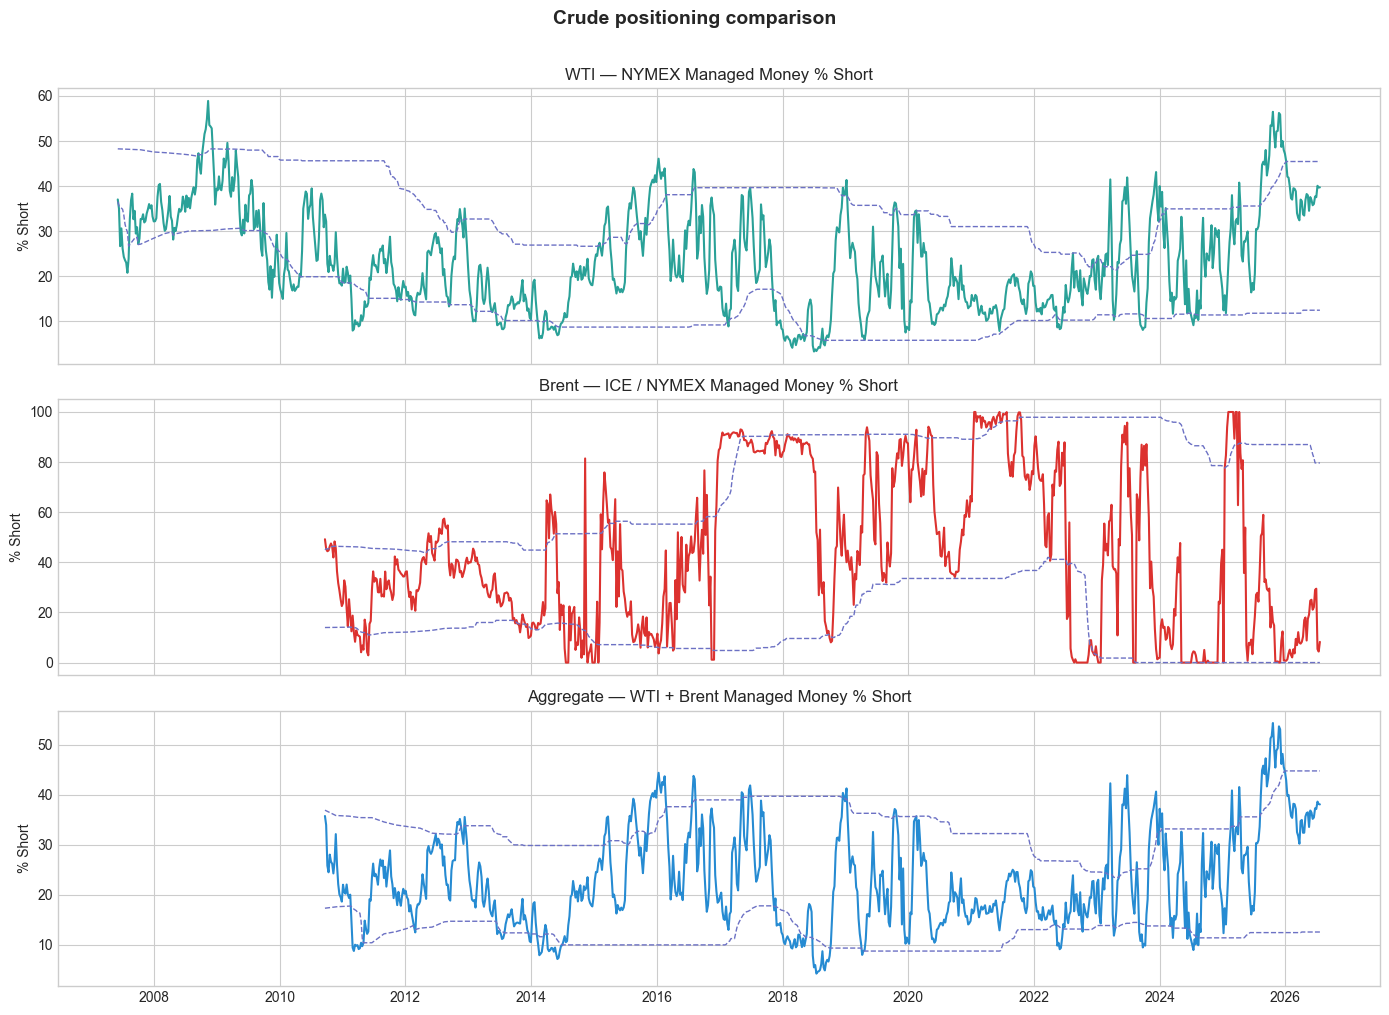

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

series_specs = [
    (wti, "WTI — NYMEX Managed Money % Short", "#2aa198"),
    (brent, "Brent — ICE / NYMEX Managed Money % Short", "#dc322f"),
    (agg, "Aggregate — WTI + Brent Managed Money % Short", "#268bd2"),
]

for ax, (df, title, color) in zip(axes, series_specs):
    plot_df = df.dropna(subset=["upper", "lower"])
    ax.plot(plot_df["report_date"], plot_df["pct_short"], color=color, linewidth=1.5)
    ax.plot(plot_df["report_date"], plot_df["upper"], color="#6c71c4", linestyle="--", linewidth=1)
    ax.plot(plot_df["report_date"], plot_df["lower"], color="#6c71c4", linestyle="--", linewidth=1)
    ax.set_title(title)
    ax.set_ylabel("% Short")

axes[-1].xaxis.set_major_locator(mdates.YearLocator(base=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Crude positioning comparison", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

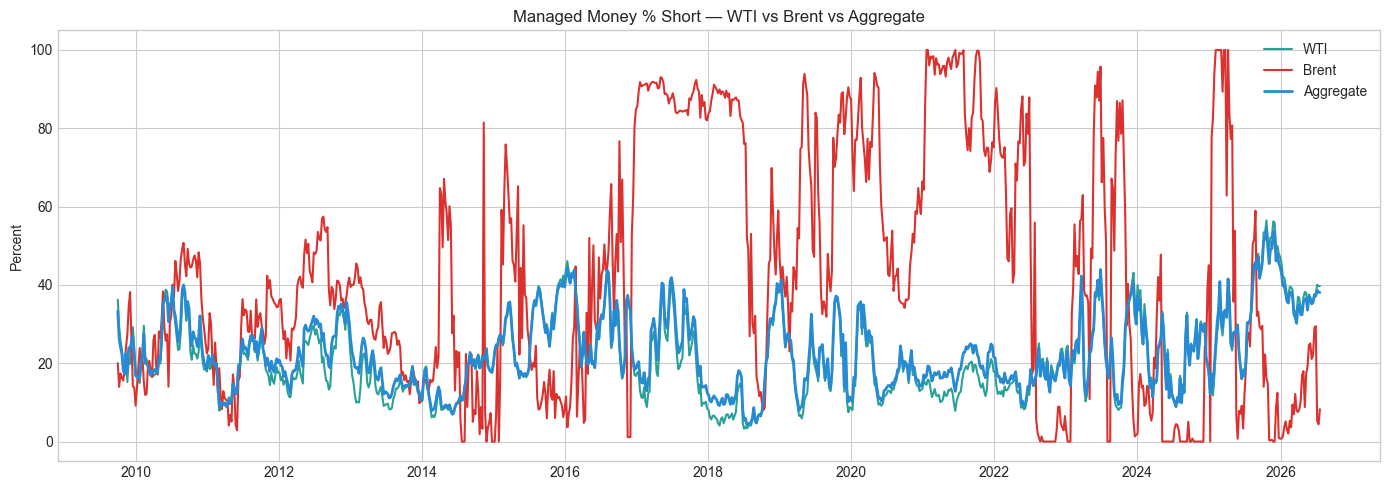

Latest: WTI=39.7% Brent=8.3% Agg=38.1%


In [7]:
compare = wti[["report_date", "pct_short"]].rename(columns={"pct_short": "wti"})
compare = compare.merge(
    brent[["report_date", "pct_short"]].rename(columns={"pct_short": "brent"}),
    on="report_date",
    how="inner",
)
compare = compare.merge(
    agg[["report_date", "pct_short"]].rename(columns={"pct_short": "aggregate"}),
    on="report_date",
    how="inner",
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(compare["report_date"], compare["wti"], label="WTI", color="#2aa198", linewidth=1.5)
ax.plot(compare["report_date"], compare["brent"], label="Brent", color="#dc322f", linewidth=1.5)
ax.plot(compare["report_date"], compare["aggregate"], label="Aggregate", color="#268bd2", linewidth=2)
ax.set_title("Managed Money % Short — WTI vs Brent vs Aggregate")
ax.set_ylabel("Percent")
ax.legend()
fig.tight_layout()
plt.show()

print(
    "Latest:",
    f"WTI={compare['wti'].iloc[-1]:.1f}%",
    f"Brent={compare['brent'].iloc[-1]:.1f}%",
    f"Agg={compare['aggregate'].iloc[-1]:.1f}%",
)

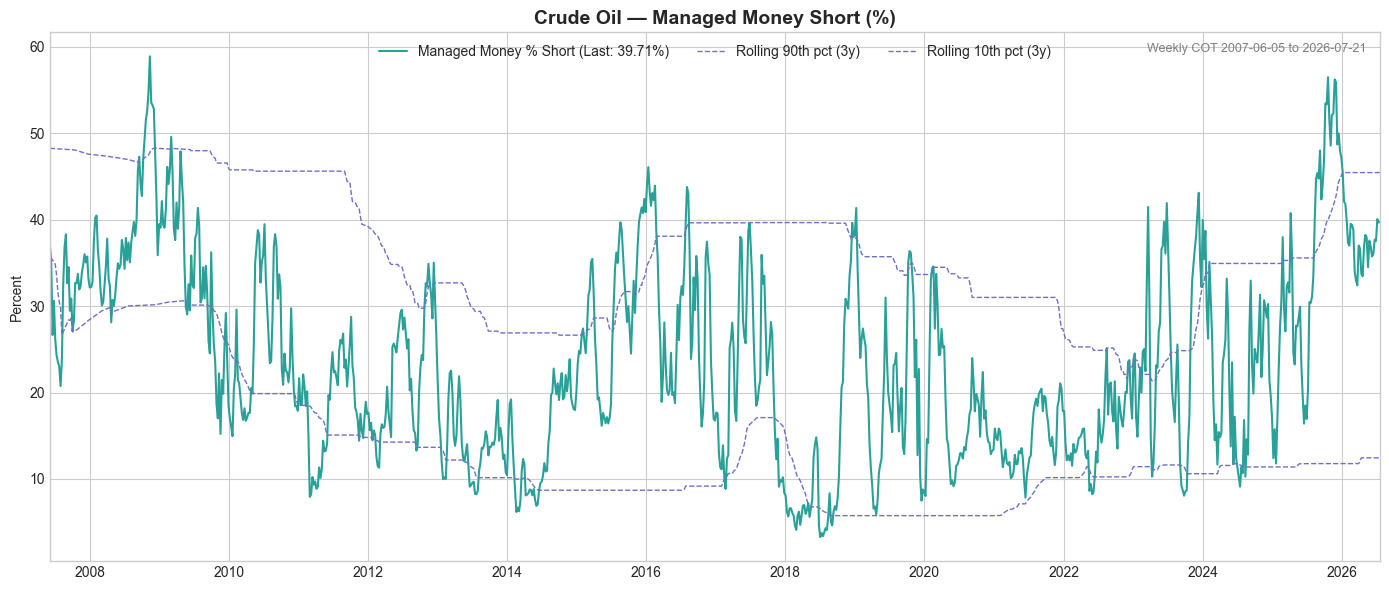

In [8]:
plot_df = cot.dropna(subset=["upper", "lower"]).copy()
last_val = plot_df["pct_short"].iloc[-1]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(plot_df["report_date"], plot_df["pct_short"], color="#2aa198", linewidth=1.5,
        label=f"Managed Money % Short (Last: {last_val:.2f}%)")
ax.plot(plot_df["report_date"], plot_df["upper"], color="#6c71c4", linestyle="--", linewidth=1,
        label="Rolling 90th pct (3y)")
ax.plot(plot_df["report_date"], plot_df["lower"], color="#6c71c4", linestyle="--", linewidth=1,
        label="Rolling 10th pct (3y)")

ax.set_title("Crude Oil — Managed Money Short (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Percent")
ax.set_xlabel("")
ax.legend(loc="upper center", ncol=3, frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(plot_df["report_date"].min(), plot_df["report_date"].max())

freq = f"Weekly COT {plot_df['report_date'].min():%Y-%m-%d} to {plot_df['report_date'].max():%Y-%m-%d}"
ax.text(0.99, 0.98, freq, transform=ax.transAxes, ha="right", va="top", fontsize=9, color="gray")

fig.tight_layout()
plt.show()

## 3. How to use this indicator

### Contrarian extremes (3Fourteen style)
- **% short spikes above upper band** → funds are capitulating / heavily short → watch for **long** setups or cover rallies.
- **% short falls below lower band** → crowded long → watch for **short** setups or long liquidation.

### Trend confirmation
- Rising price + falling % short = new longs being added (bullish confirmation).
- Falling price + rising % short = new shorts being added (bearish confirmation).

### What it is *not*
- Not a timing tool by itself — extremes can persist.
- Not real-time — 3-day publication lag.
- Spread positions are excluded from the numerator/denominator (directional long + short only).

### Overlay ideas
- Plot alongside WTI price (second axis).
- Combine with inventory, curve structure, or macro risk-on/off filters before sizing trades.

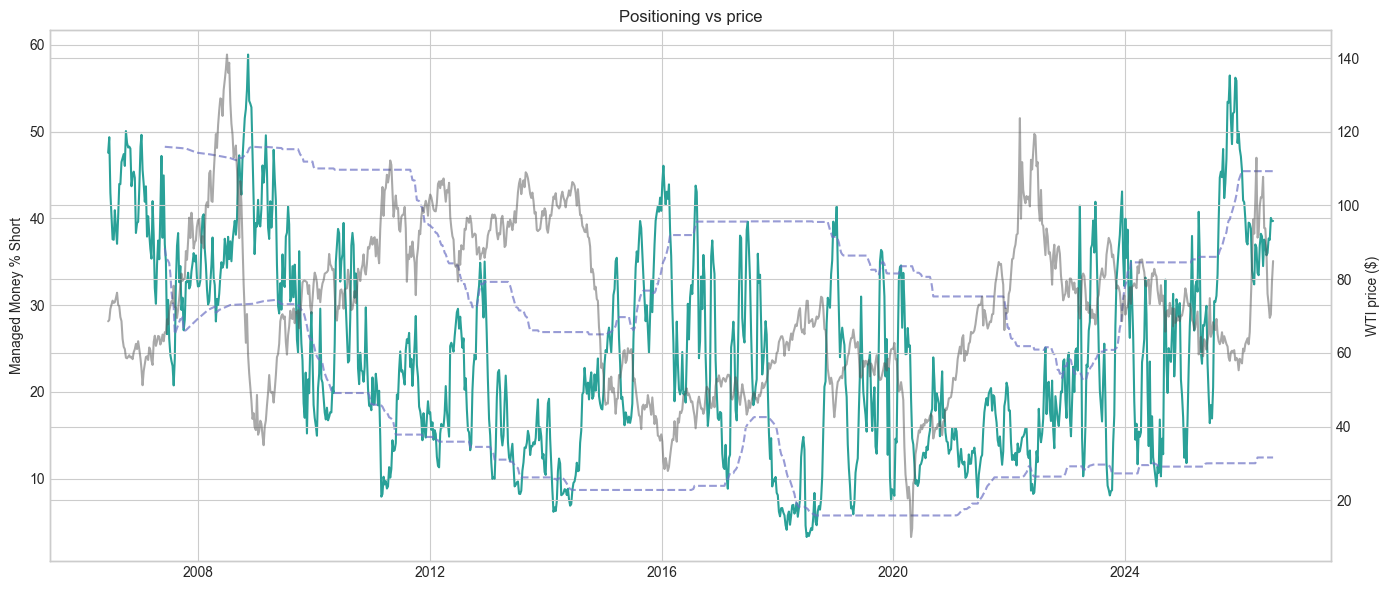

In [9]:
prices = fetch_wti_prices(start="2006-01-01")

overlay = cot.merge(prices.rename("wti"), left_on="report_date", right_index=True, how="inner")

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.plot(overlay["report_date"], overlay["pct_short"], color="#2aa198", label="% Short")
ax1.plot(overlay["report_date"], overlay["upper"], color="#6c71c4", linestyle="--", alpha=0.7)
ax1.plot(overlay["report_date"], overlay["lower"], color="#6c71c4", linestyle="--", alpha=0.7)
ax2.plot(overlay["report_date"], overlay["wti"], color="#555555", alpha=0.5, label="WTI (CL=F)")

ax1.set_ylabel("Managed Money % Short")
ax2.set_ylabel("WTI price ($)")
ax1.set_title("Positioning vs price")
fig.tight_layout()
plt.show()

## 4. Backtest: contrarian extremes

Simple weekly rules (for learning — not production-ready):

| Signal | Action |
|--------|--------|
| Prior week % short ≥ rolling 90th pct | **Go long** WTI next week |
| Prior week % short ≤ rolling 10th pct | **Go short** WTI next week |
| Long & % short crosses back ≤ median | **Exit** to flat |
| Short & % short crosses back ≥ median | **Exit** to flat |

**Assumptions:** CL=F continuous futures, weekly returns aligned to COT report dates, no transaction costs, thresholds use only past data (shifted by one week when trading).

In [10]:
bt, trades = backtest_contrarian_extremes(cot, prices)
stats = summarize_backtest(bt)

pd.Series(stats)

label                    Contrarian COT
weeks                              1035
total_return                  -0.126241
buy_hold_return                0.238477
sharpe                         0.160719
max_drawdown                  -0.894799
win_rate_active_weeks          0.509615
pct_time_in_market             0.501931
dtype: object

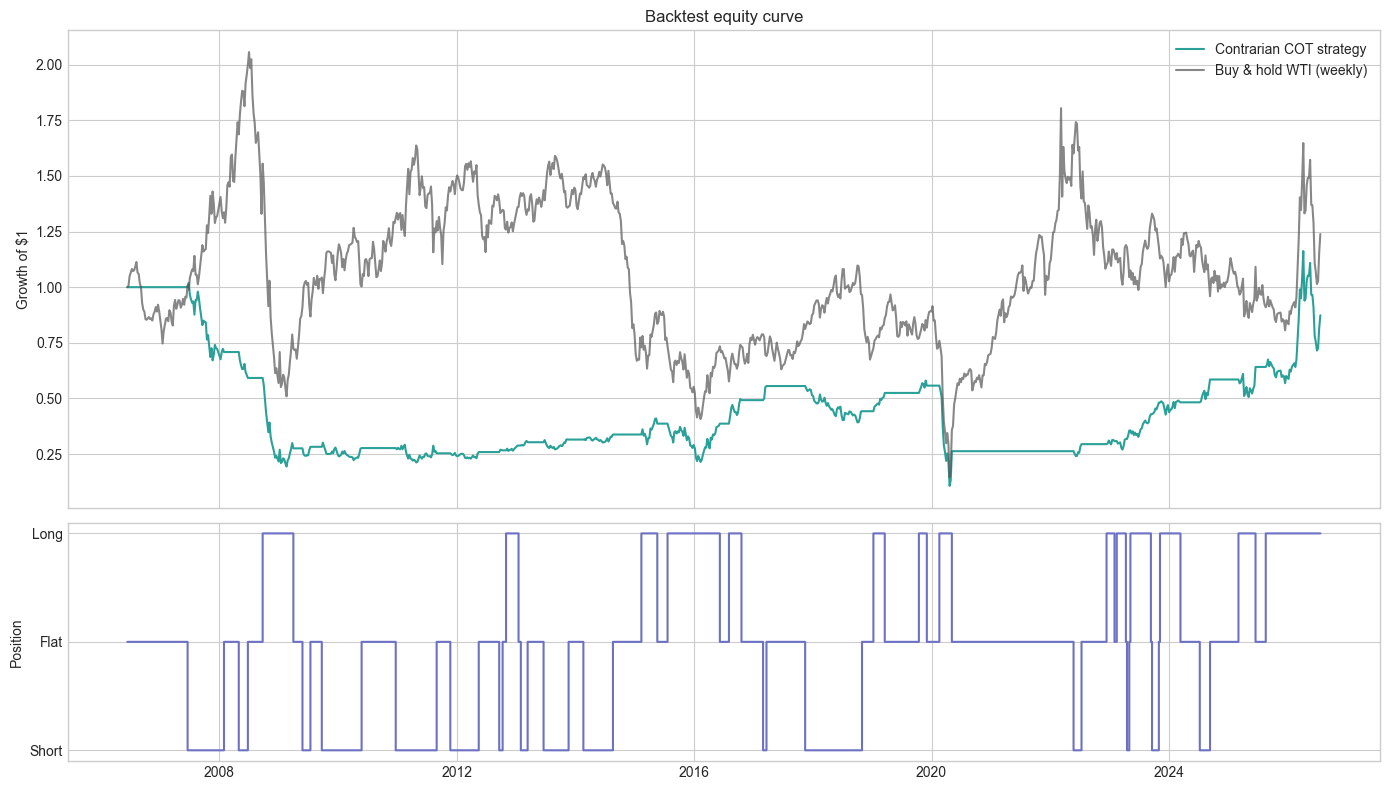

In [11]:
eq = (1 + bt["strategy_ret"].fillna(0)).cumprod()
bh = (1 + bt["ret_1w"].fillna(0)).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(bt["report_date"], eq, label="Contrarian COT strategy", color="#2aa198")
axes[0].plot(bt["report_date"], bh, label="Buy & hold WTI (weekly)", color="#555555", alpha=0.7)
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].set_title("Backtest equity curve")

axes[1].step(bt["report_date"], bt["position"], where="post", color="#6c71c4")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short", "Flat", "Long"])
axes[1].set_ylabel("Position")

fig.tight_layout()
plt.show()

In [12]:
print(f"Trade count: {len(trades)}")
trades.tail(10)

Trade count: 59


,date,from_position,to_position,pct_short,upper,lower,price
49,2023-09-12,1,0,11.761307,24.841225,11.617368,88.839996
50,2023-09-19,0,-1,9.186860,24.841225,11.558818,91.199997
51,2023-10-31,-1,0,17.315108,24.841225,10.600372,81.019997
52,2023-11-07,0,1,27.650019,24.976646,10.600372,77.370003
53,2024-03-12,1,0,14.486804,34.934739,10.600372,77.559998
54,2024-07-09,0,-1,11.371685,34.934739,11.757580,81.410004
55,2024-09-10,-1,0,27.253927,34.934739,11.383797,65.750000
56,2025-03-04,0,1,37.980152,35.280447,11.383797,68.260002
57,2025-06-17,1,0,19.590772,35.570782,11.773935,74.839996
58,2025-08-19,0,1,39.783310,35.878003,11.773935,62.349998


## 5. Parameter sensitivity (optional)

Sweep rolling window and quantile cutoffs to see how fragile the contrarian edge is.

In [13]:
rows = []
base = load_disaggregated_raw(use_cache=True)

for window in [104, 156, 208]:
    for upper, lower in [(0.90, 0.10), (0.85, 0.15), (0.95, 0.05)]:
        cfg = add_rolling_thresholds(base, window=window, upper_q=upper, lower_q=lower)
        res, _ = backtest_contrarian_extremes(cfg, prices)
        s = summarize_backtest(res, label=f"w={window} u={upper} l={lower}")
        rows.append(s)

pd.DataFrame(rows).sort_values("total_return", ascending=False)

,label,weeks,total_return,buy_hold_return,sharpe,max_drawdown,win_rate_active_weeks,pct_time_in_market
5,w=156 u=0.95 l=0.05,1035,1.310834,0.238477,0.292649,-0.657455,0.507500,0.386100
8,w=208 u=0.95 l=0.05,1035,0.313883,0.238477,0.180944,-0.679544,0.508353,0.404440
2,w=104 u=0.95 l=0.05,1035,0.179271,0.238477,0.160822,-0.724316,0.508969,0.430502
4,w=156 u=0.85 l=0.15,1035,0.076155,0.238477,0.195891,-0.851467,0.510334,0.607143
3,w=156 u=0.9 l=0.1,1035,-0.126241,0.238477,0.160719,-0.894799,0.509615,0.501931
6,w=208 u=0.9 l=0.1,1035,-0.136849,0.238477,0.112763,-0.872290,0.510166,0.522201
0,w=104 u=0.9 l=0.1,1035,-0.622187,0.238477,0.054177,-0.928962,0.498120,0.513514
7,w=208 u=0.85 l=0.15,1035,-0.729140,0.238477,-0.013995,-0.925044,0.503962,0.609073
1,w=104 u=0.85 l=0.15,1035,-0.859150,0.238477,-0.049488,-0.961293,0.483619,0.618726


## Takeaways

1. **Managed Money % Short** = directional bearishness within the fund/CTA cohort, not % of total market OI.
2. Use **Disaggregated COT** and stitch NYMEX label changes for continuous WTI and Brent series.
3. **WTI and Brent can diverge** — aggregate smooths this by pooling MM long/short across both benchmarks.
4. **Rolling percentile bands** adapt to regime; fixed 28/12 lines are a useful reference but not sacred.
5. A naive contrarian backtest is a starting point — add costs, filters, and combine with fundamentals before trusting live sizing.

**Next steps:** wire into `trading_indicators/backtest` as a weekly macro overlay, add ICE WTI as a third aggregate leg, or pull from Bloomberg (`CFTCCL Index`) for daily forward-fill.